#**EDA**

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('/content/Food_Delivery_Time_Prediction[2].csv')
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [20]:
df.shape

(50000, 24)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

In [22]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Order_Hour,0
Day_of_Week,0
Is_Weekend,0
Is_Festival,0
Weather,0
Pickup_Zone,0
Dropoff_Zone,0
Vehicle_Type,0


In [23]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [24]:
print("num_cols: ", numerical_cols)
print("cat_cols: ", cat_cols)

num_cols:  Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')
cat_cols:  Index(['Order_ID', 'Order_Date', 'Day_of_Week', 'Weather', 'Pickup_Zone',
       'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load',
       'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority'],
      dtype='object')


In [25]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
categorical_data = ['Day_of_Week', 'Weather', 'Pickup_Zone',
       'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load',
       'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']

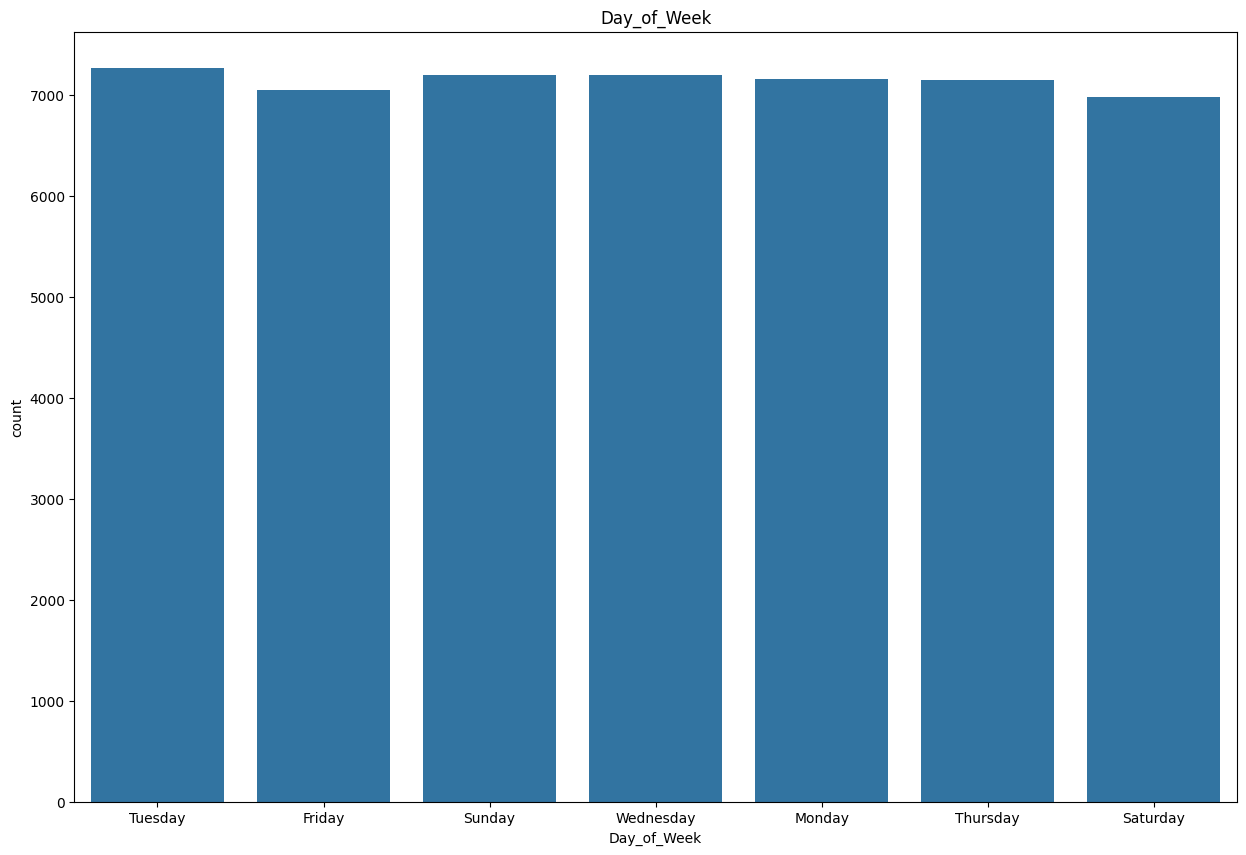

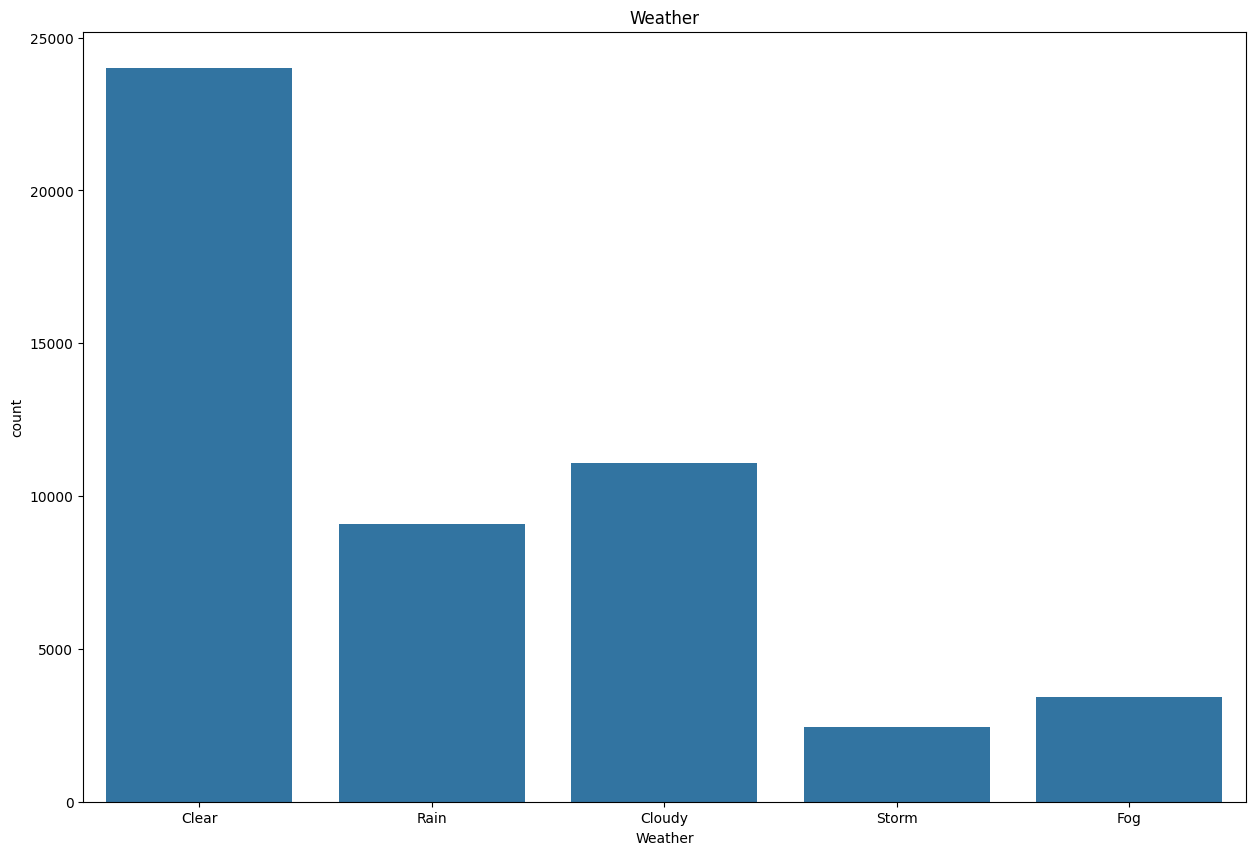

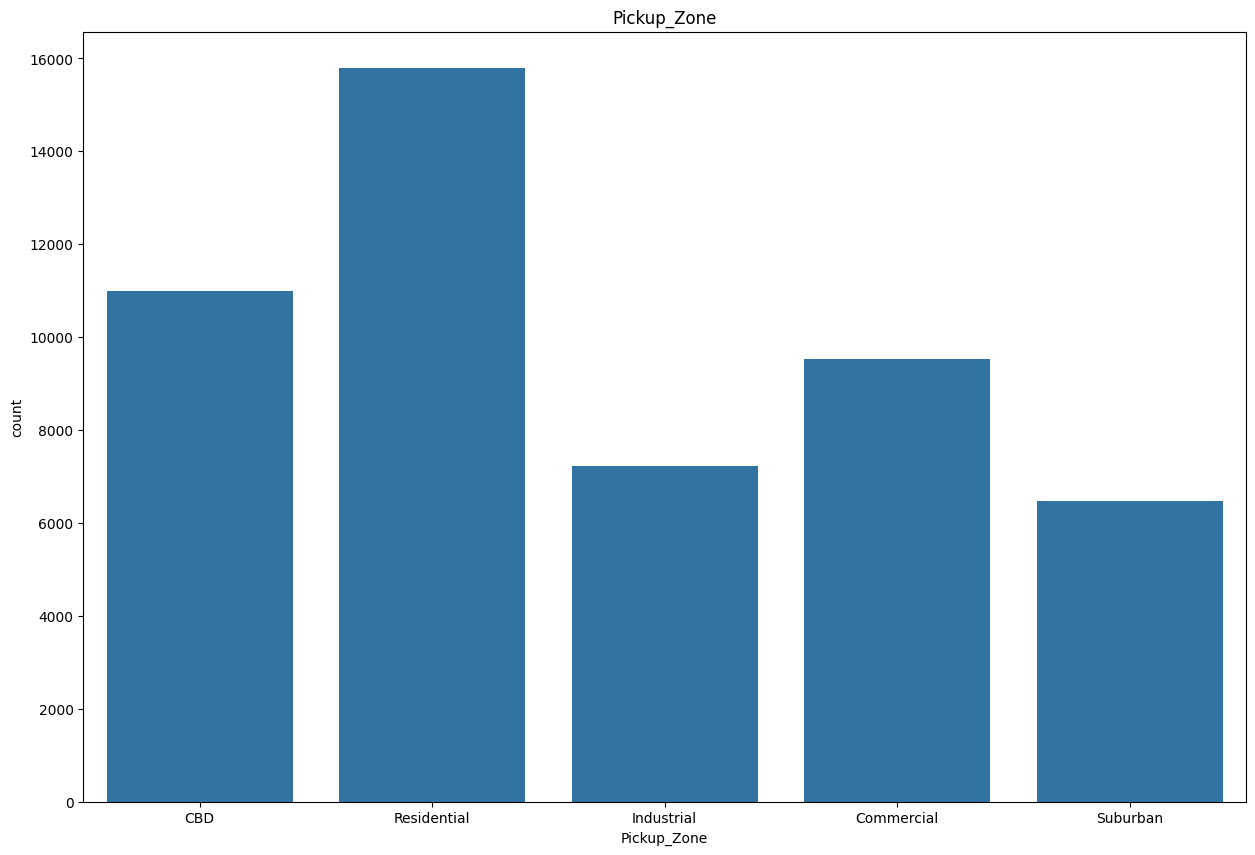

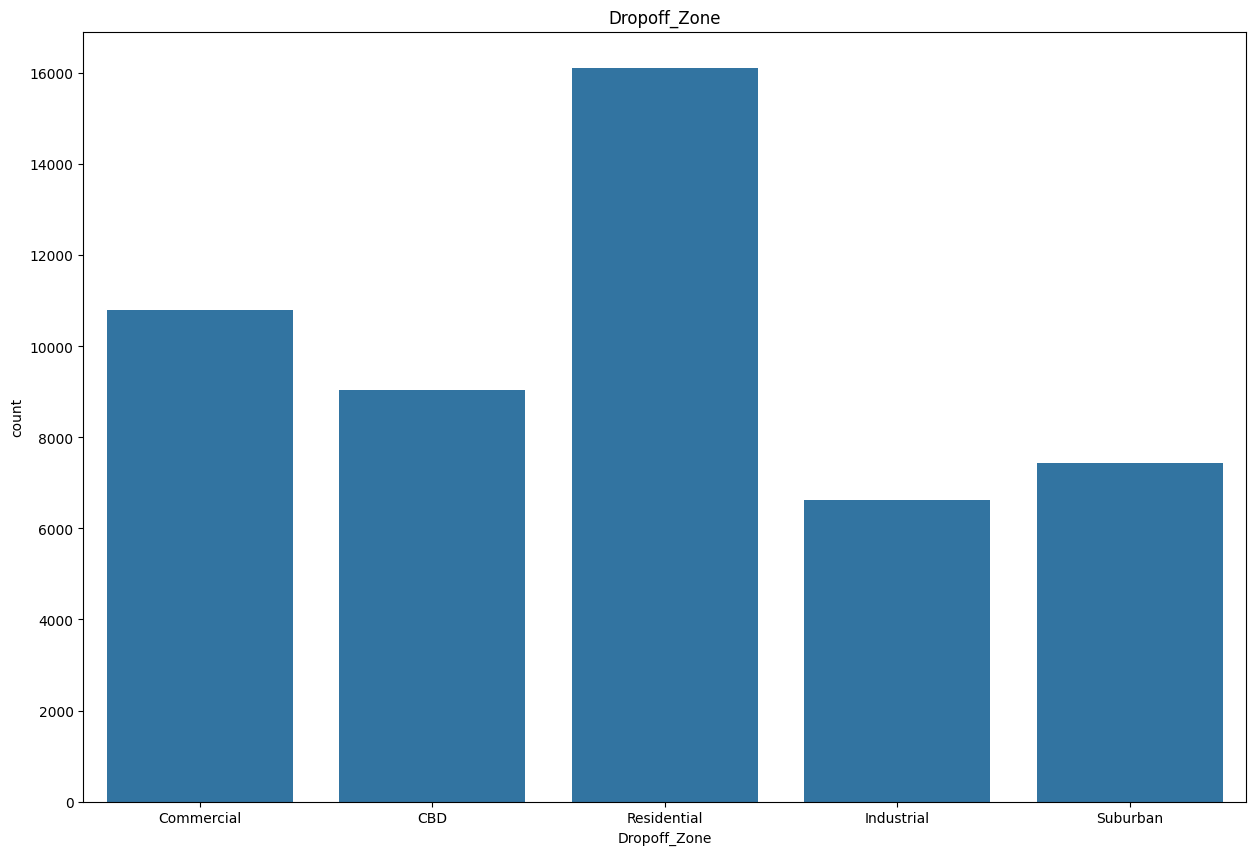

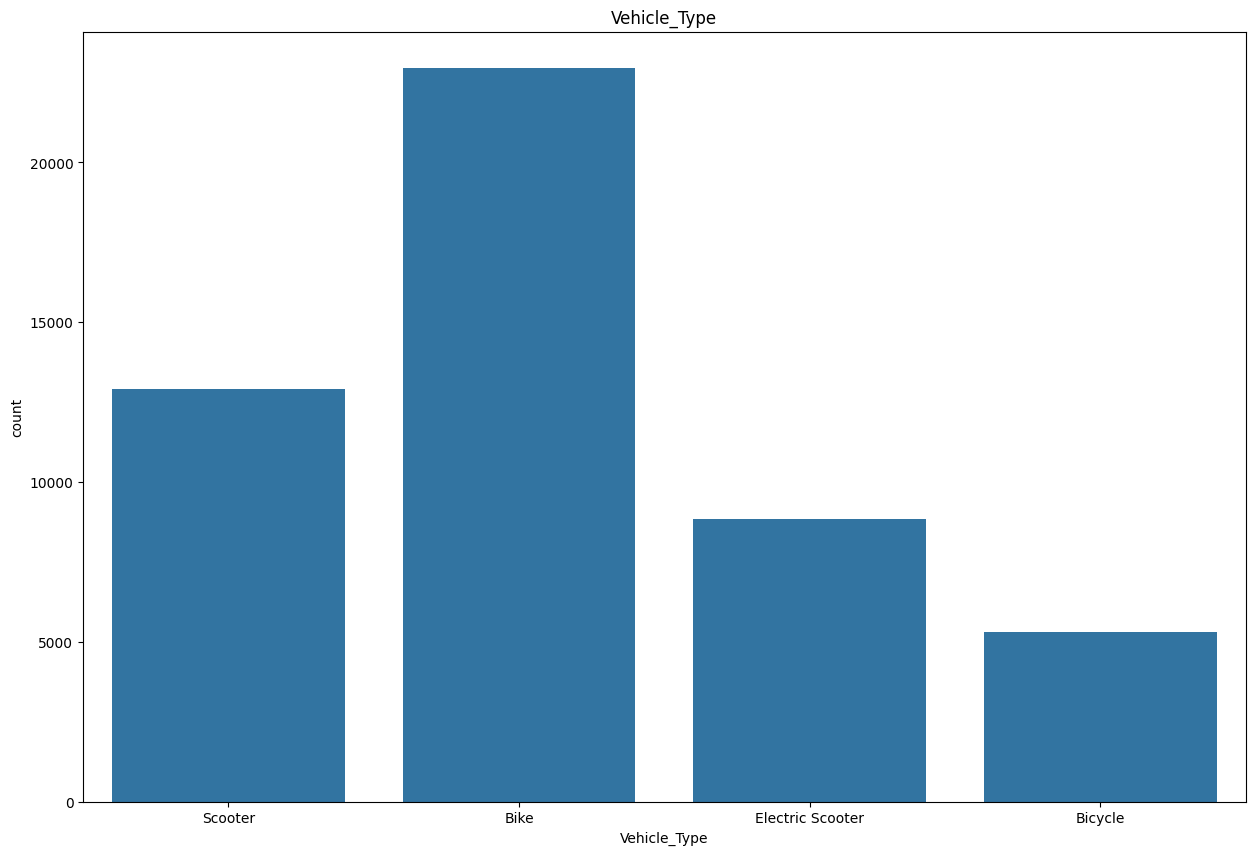

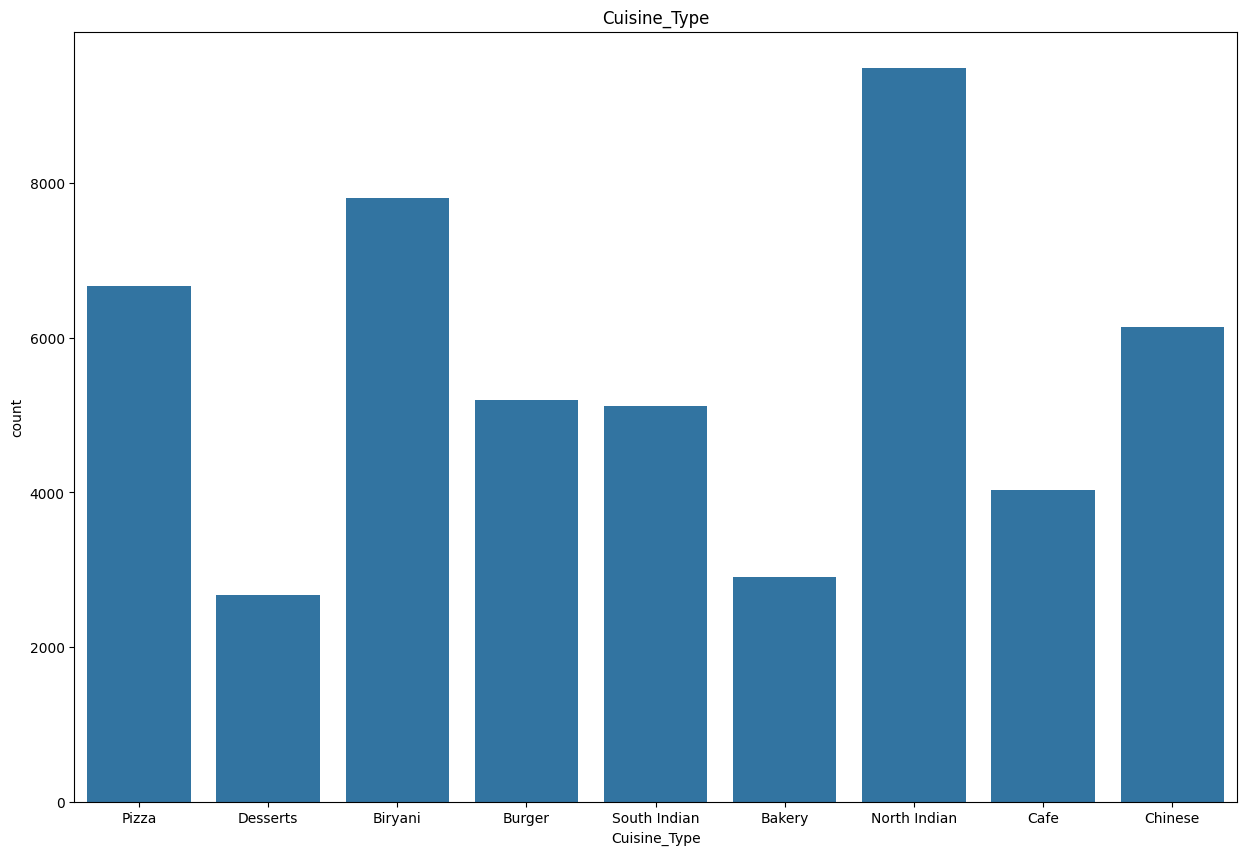

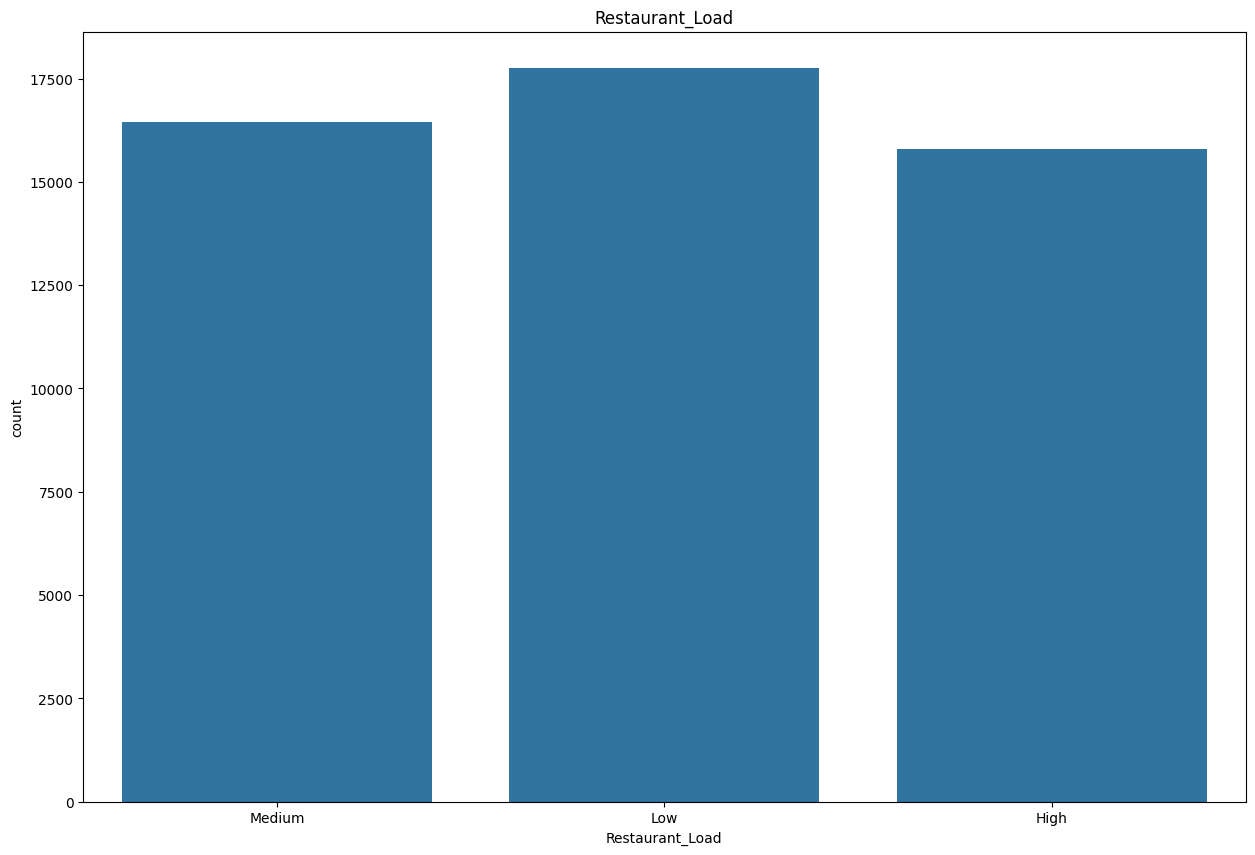

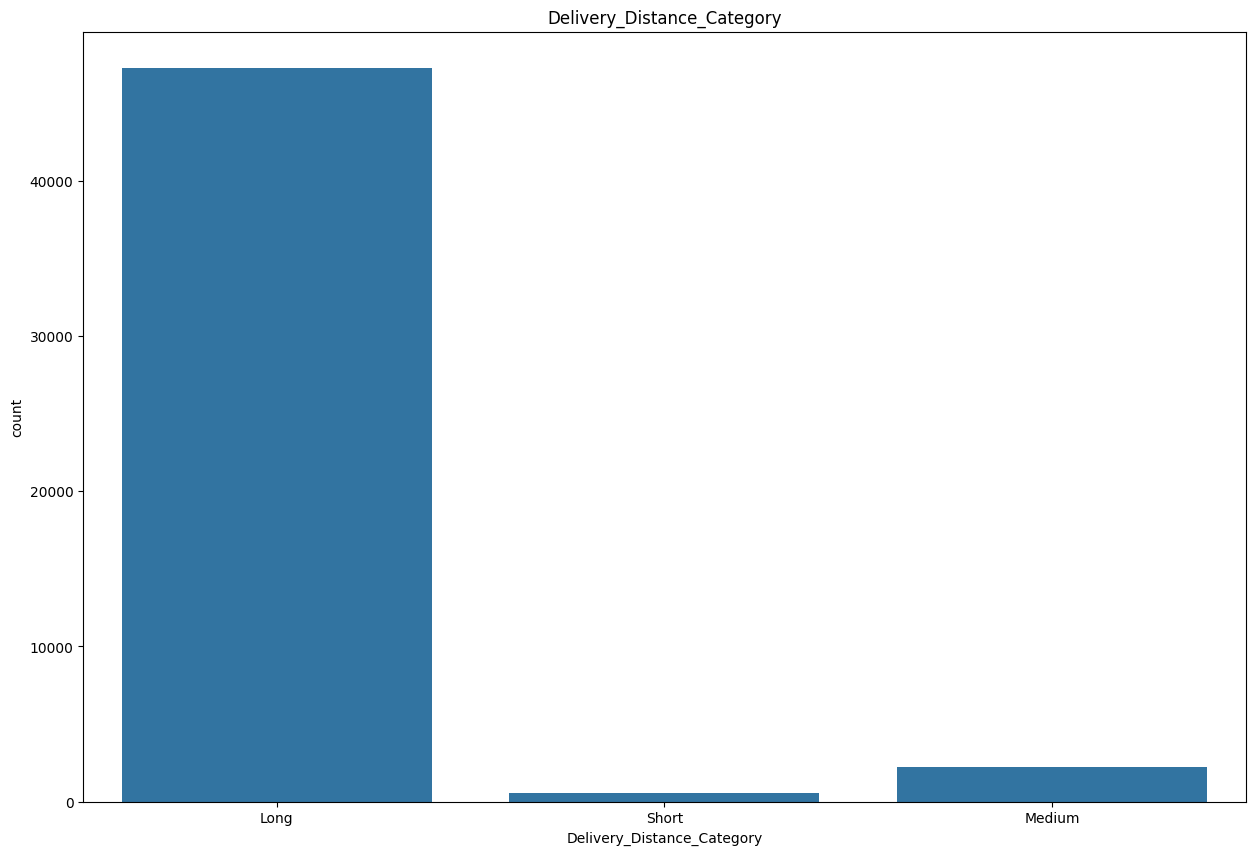

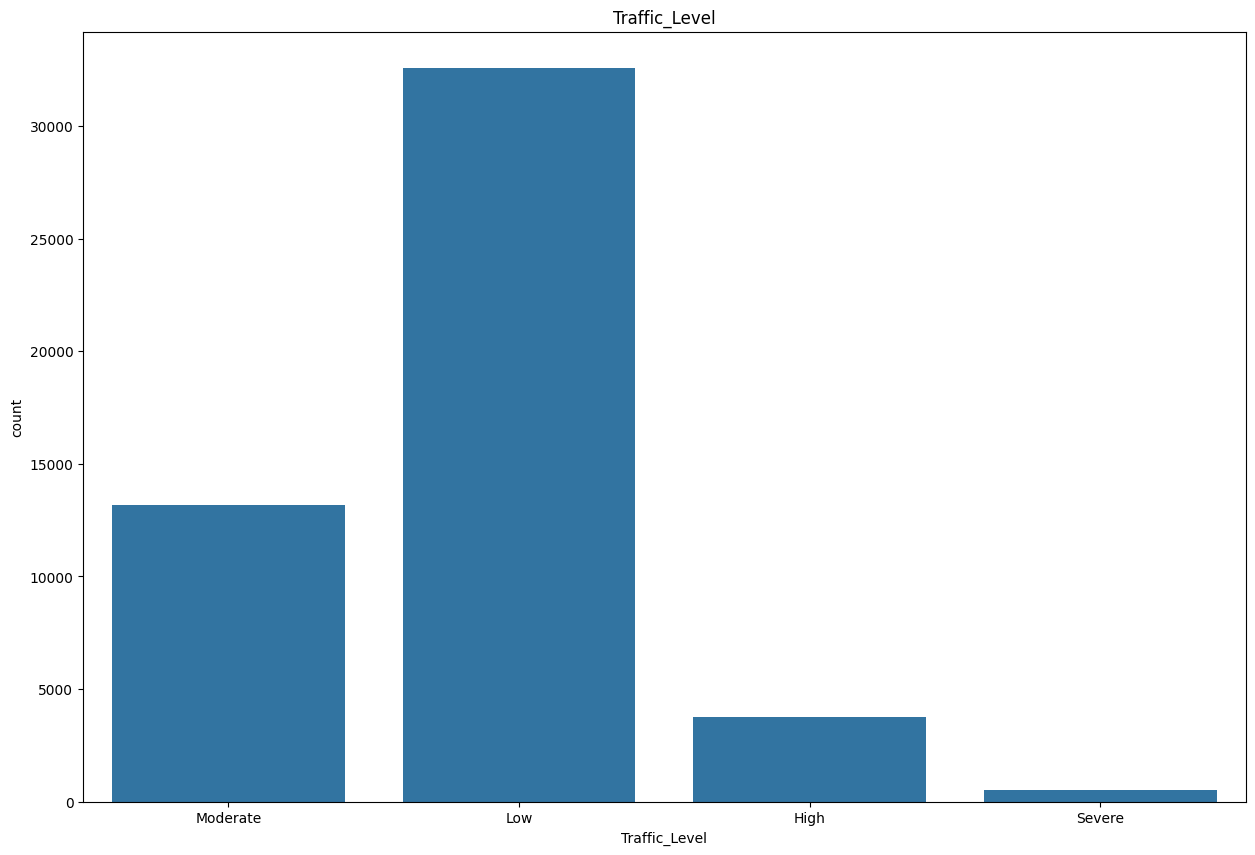

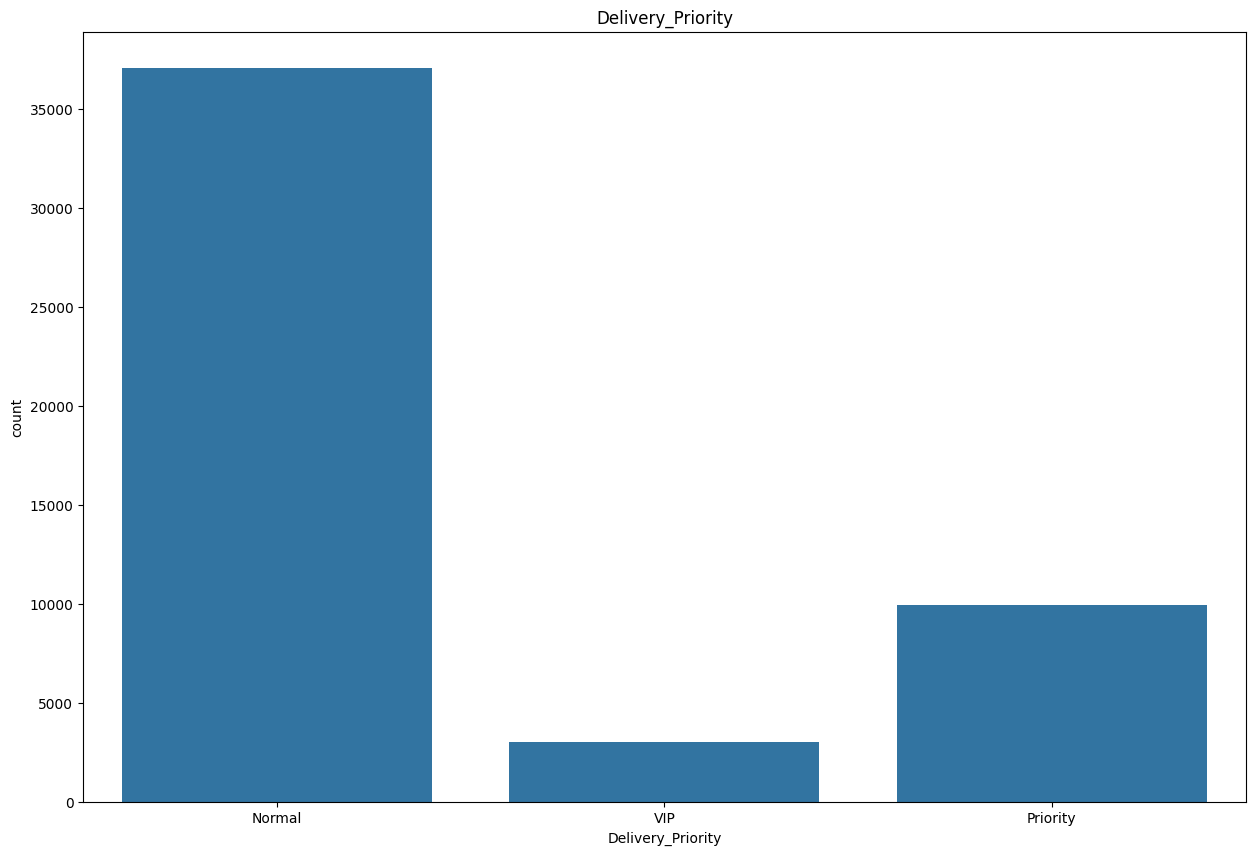

In [28]:
for col in categorical_data:
    plt.figure(figsize=(15,10))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

In [29]:
for col in cat_cols:
   print(col)
   print(df[col].unique())
   print("------------------------------------------------------------")

Order_ID
['ORD000001' 'ORD000002' 'ORD000003' ... 'ORD049998' 'ORD049999'
 'ORD050000']
------------------------------------------------------------
Order_Date
['2025-10-28' '2025-09-26' '2025-01-26' '2025-11-19' '2025-08-04'
 '2025-01-22' '2025-08-19' '2025-04-11' '2025-01-23' '2025-09-19'
 '2025-06-03' '2025-01-12' '2025-10-12' '2025-06-24' '2025-07-13'
 '2025-02-21' '2025-09-28' '2025-09-30' '2025-04-29' '2025-12-18'
 '2025-06-26' '2025-01-25' '2025-07-24' '2025-07-04' '2025-03-02'
 '2025-03-03' '2025-10-01' '2025-09-15' '2025-10-09' '2025-12-23'
 '2025-12-12' '2025-09-04' '2025-03-05' '2025-03-21' '2025-02-16'
 '2025-06-22' '2025-07-06' '2025-07-28' '2025-01-13' '2025-03-17'
 '2025-12-29' '2025-04-26' '2025-05-11' '2025-09-27' '2025-08-05'
 '2025-04-27' '2025-04-17' '2025-03-28' '2025-03-24' '2025-08-16'
 '2025-10-10' '2025-09-23' '2025-10-16' '2025-05-13' '2025-03-20'
 '2025-02-12' '2025-11-03' '2025-03-14' '2025-05-19' '2025-08-23'
 '2025-05-10' '2025-04-25' '2025-11-04' '2025-03

In [30]:
def detect_outliers_iqr(df, columns):
    results = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        results.append({
            'Column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outliers Count': len(outliers),
            'Outliers %': len(outliers) / len(df) * 100
        })

    return pd.DataFrame(results)

In [31]:
outlier_results = detect_outliers_iqr(df, numerical_cols)
outlier_results

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Count,Outliers %
0,Order_Hour,10.00,19.00,9.00,-3.500,32.500,0,0.000
1,Is_Weekend,0.00,1.00,1.00,-1.500,2.500,0,0.000
2,Is_Festival,0.00,0.00,0.00,0.000,0.000,2455,4.910
3,Rider_Experience_Years,2.20,5.90,3.70,-3.350,11.450,1748,3.496
4,Rider_Rating,3.70,4.10,0.40,3.100,4.700,1290,2.580
5,Restaurant_Rating,3.90,4.40,0.50,3.150,5.150,0,0.000
6,Order_Items,1.00,4.00,3.00,-3.500,8.500,0,0.000
7,Preparation_Time_Min,18.00,30.00,12.00,0.000,48.000,7,0.014
8,Road_Distance_km,16.33,35.48,19.15,-12.395,64.205,32,0.064
9,Number_of_Signals,6.00,14.00,8.00,-6.000,26.000,0,0.000


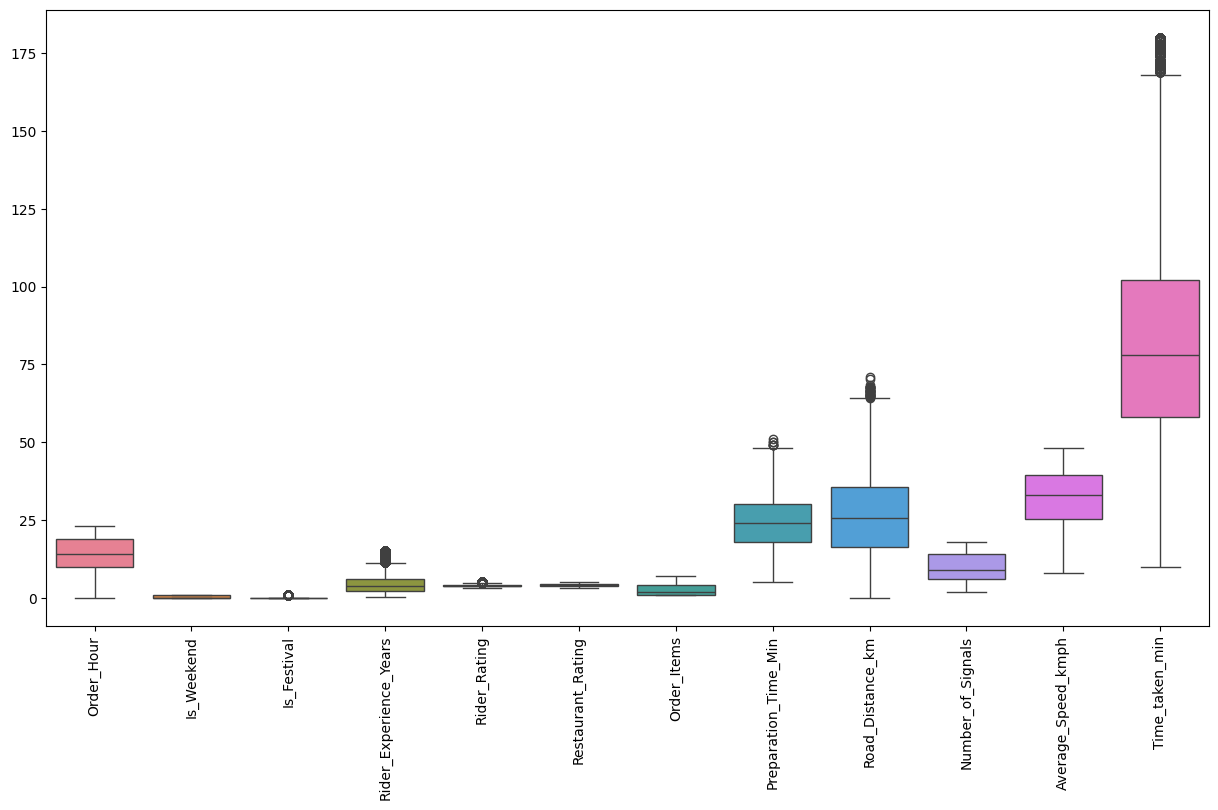

In [32]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.show()

In [33]:
for col in numerical_cols:
   print(col)
   print(df[col].unique())
   print("------------------------------------------------------------")

Order_Hour
[ 8 12 18 22 16 17 21  7 11 10 15  5 20 19 14 13 23  9  6  2  1  4  0  3]
------------------------------------------------------------
Is_Weekend
[0 1]
------------------------------------------------------------
Is_Festival
[0 1]
------------------------------------------------------------
Rider_Experience_Years
[ 3.1  1.8  3.8  1.7 12.4  1.6  2.2  0.7 10.2  9.3  2.8  9.2  7.2  1.4
  6.   5.3  2.5  4.3  4.  15.   6.6  8.8  5.4  0.8  6.3  6.9  1.1  5.6
  1.3  7.9  3.6  5.2 10.3  4.1  5.7  2.4  2.7  3.9  3.7  9.4  5.5  2.3
  2.1  4.4  2.   4.9 13.   3.2  2.6  3.   9.1  5.1  3.4 12.   4.6  3.5
  6.7 14.6  4.2  3.3  0.6  5.   2.9  4.5  7.   8.2  1.2  1.9 10.9  6.1
  4.8  9.   1.5  0.4  5.9  0.9  7.4  8.9 12.6  7.8  7.3 11.6  8.5  8.1
  8.6  6.2 14.8  1.   7.1  9.8  6.4  4.7  9.5 11.   7.7  0.5  0.3  0.1
  8.7 11.3 10.5  8.   9.7  6.5  5.8 12.1  7.5 10.7  8.3  6.8 10.4 12.5
 10.   9.6  0.2 13.5 12.2 13.6 13.3  8.4  9.9 11.9 14.  10.1  7.6 14.4
 10.6 11.8 12.3]
------------------

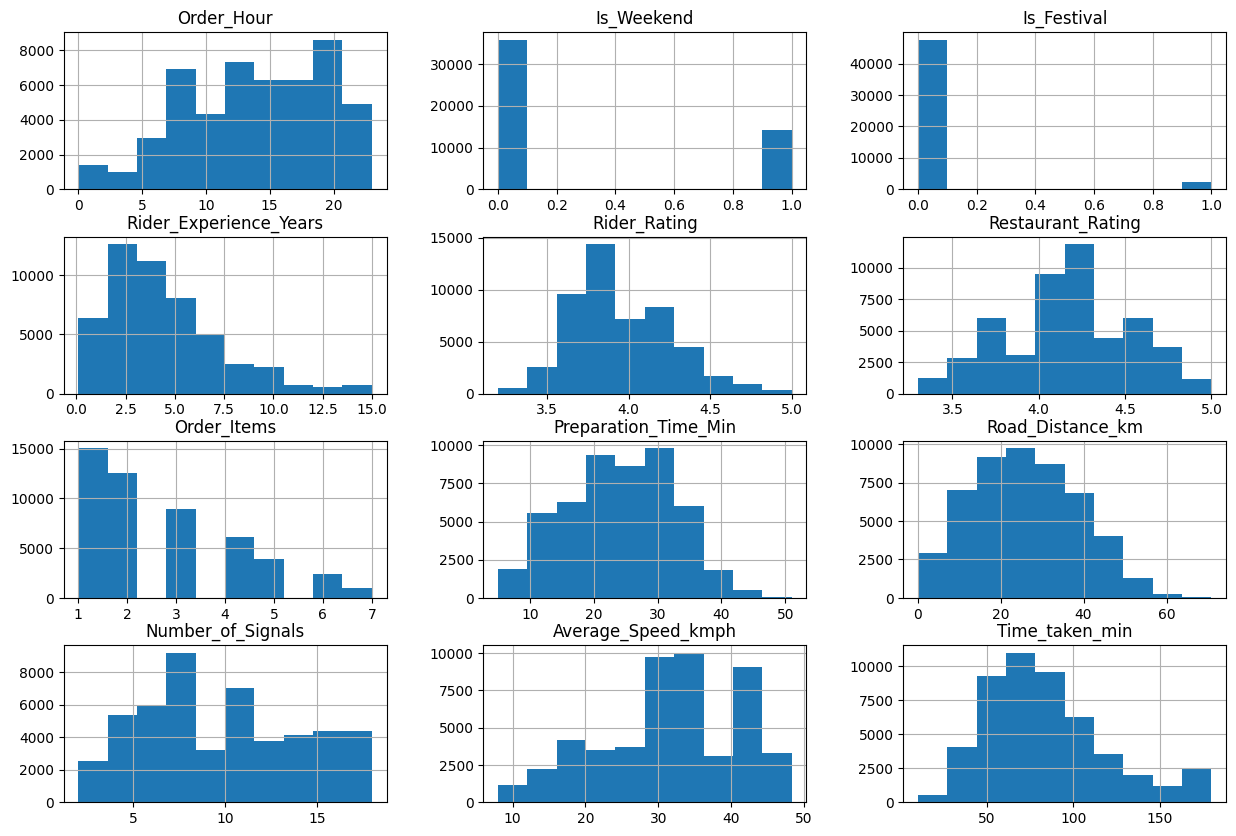

In [34]:
df[numerical_cols].hist(figsize=(15,10))
plt.show()

In [35]:
for col in cat_cols:
    print(df[col].value_counts())
    print("-"*30)

Order_ID
ORD049984    1
ORD049983    1
ORD049982    1
ORD049981    1
ORD049980    1
            ..
ORD000005    1
ORD000004    1
ORD000003    1
ORD000002    1
ORD000001    1
Name: count, Length: 50000, dtype: int64
------------------------------
Order_Date
2025-02-12    170
2025-04-10    169
2025-08-05    168
2025-03-30    167
2025-10-09    166
             ... 
2025-07-19    111
2025-12-01    110
2025-04-05    110
2025-01-11    107
2025-01-14    106
Name: count, Length: 365, dtype: int64
------------------------------
Day_of_Week
Tuesday      7264
Sunday       7202
Wednesday    7197
Monday       7160
Thursday     7149
Friday       7050
Saturday     6978
Name: count, dtype: int64
------------------------------
Weather
Clear     23992
Cloudy    11085
Rain       9073
Fog        3413
Storm      2437
Name: count, dtype: int64
------------------------------
Pickup_Zone
Residential    15786
CBD            10997
Commercial      9523
Industrial      7233
Suburban        6461
Name: count, dtype

In [36]:
corr = df[numerical_cols].corr()
corr

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
Order_Hour,1.000000,-0.008443,-0.001141,-0.004347,-0.003895,-0.006920,-0.000056,-0.002616,-0.001648,0.003702,-0.069182,0.033687
Is_Weekend,-0.008443,1.000000,-0.002718,-0.003643,-0.004098,0.004569,-0.009761,0.000403,-0.001894,0.007765,-0.194476,0.102208
Is_Festival,-0.001141,-0.002718,1.000000,0.002951,0.003329,-0.000839,0.002475,0.000737,-0.008816,0.001763,-0.103091,0.073432
Rider_Experience_Years,-0.004347,-0.003643,0.002951,1.000000,0.782513,-0.007052,0.000222,0.000997,-0.004784,0.004410,0.133066,-0.056848
Rider_Rating,-0.003895,-0.004098,0.003329,0.782513,1.000000,0.000837,-0.001627,0.002148,-0.004164,0.005807,0.093969,-0.035992
Restaurant_Rating,-0.006920,0.004569,-0.000839,-0.007052,0.000837,1.000000,-0.002287,0.058242,0.004476,0.013462,-0.001669,0.018994
Order_Items,-0.000056,-0.009761,0.002475,0.000222,-0.001627,-0.002287,1.000000,0.381924,0.000119,-0.008885,0.007485,0.081603
Preparation_Time_Min,-0.002616,0.000403,0.000737,0.000997,0.002148,0.058242,0.381924,1.000000,-0.020162,0.103922,-0.021089,0.228123
Road_Distance_km,-0.001648,-0.001894,-0.008816,-0.004784,-0.004164,0.004476,0.000119,-0.020162,1.000000,-0.023601,-0.002157,0.702592
Number_of_Signals,0.003702,0.007765,0.001763,0.004410,0.005807,0.013462,-0.008885,0.103922,-0.023601,1.000000,-0.139685,0.127140


In [37]:
target_corr = df[numerical_cols].corr()['Time_taken_min'].sort_values(ascending=False)
print(target_corr)

Time_taken_min            1.000000
Road_Distance_km          0.702592
Preparation_Time_Min      0.228123
Number_of_Signals         0.127140
Is_Weekend                0.102208
Order_Items               0.081603
Is_Festival               0.073432
Order_Hour                0.033687
Restaurant_Rating         0.018994
Rider_Rating             -0.035992
Rider_Experience_Years   -0.056848
Average_Speed_kmph       -0.596058
Name: Time_taken_min, dtype: float64


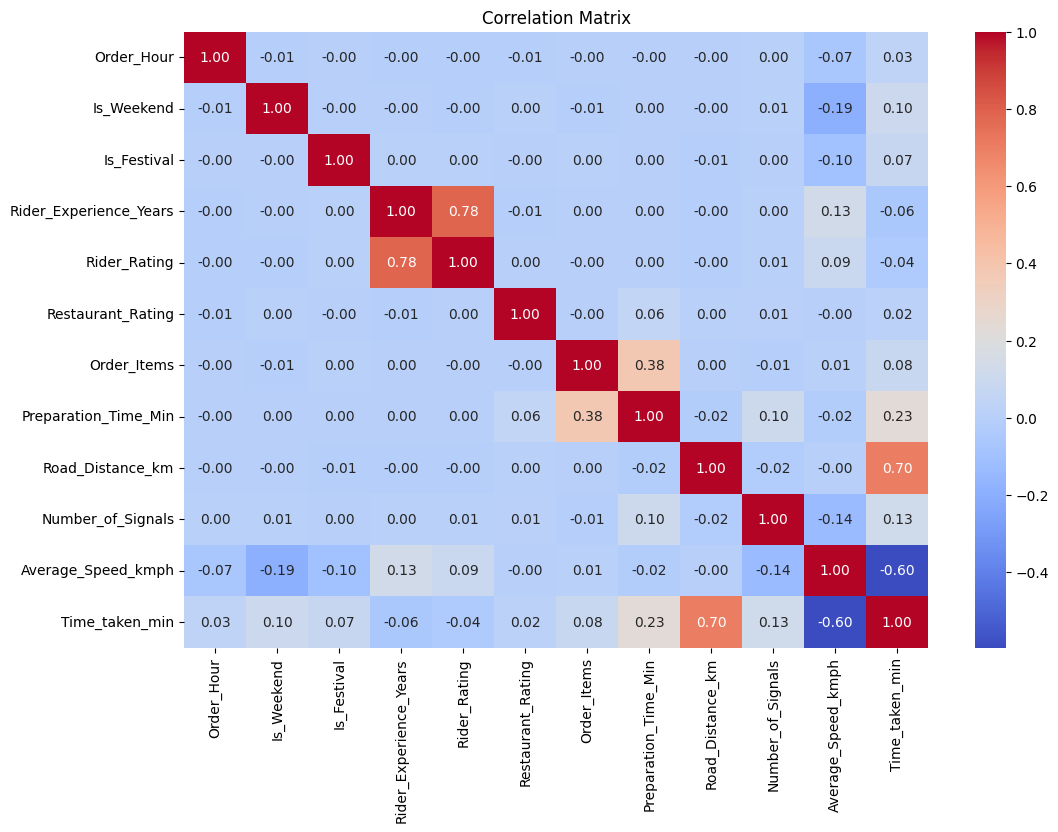

In [38]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)


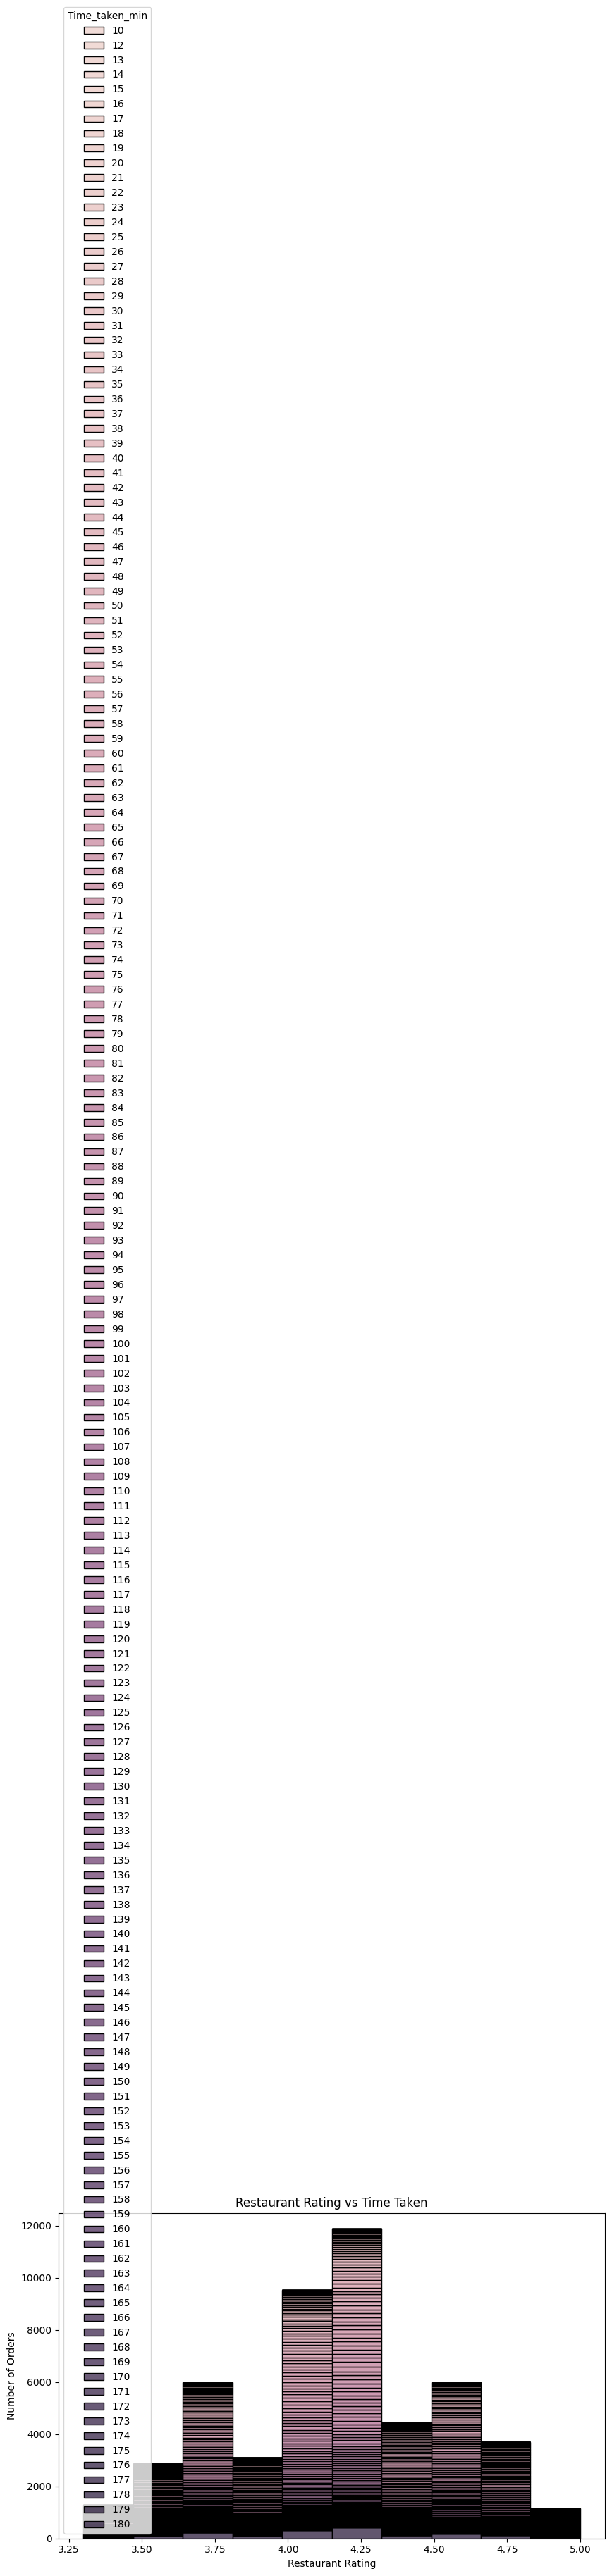

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Restaurant_Rating",
    hue="Time_taken_min",
    bins=10,
    multiple="stack"
)

plt.title("Restaurant Rating vs Time Taken")
plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Orders")

plt.show()

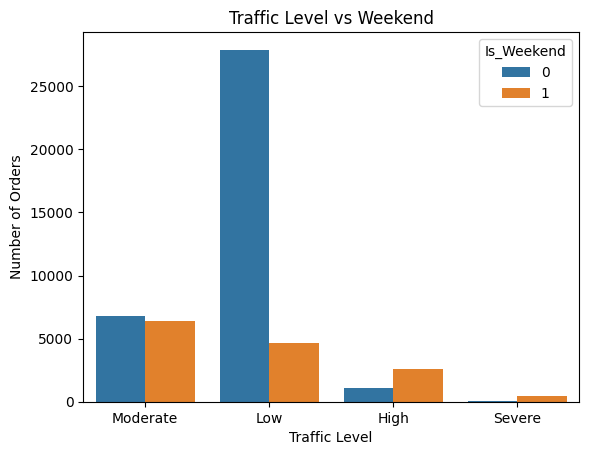

In [40]:
sns.countplot(x='Traffic_Level', hue='Is_Weekend', data=df, order=['Moderate' , 'Low' , 'High' ,'Severe'])
plt.title("Traffic Level vs Weekend")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")
plt.show()

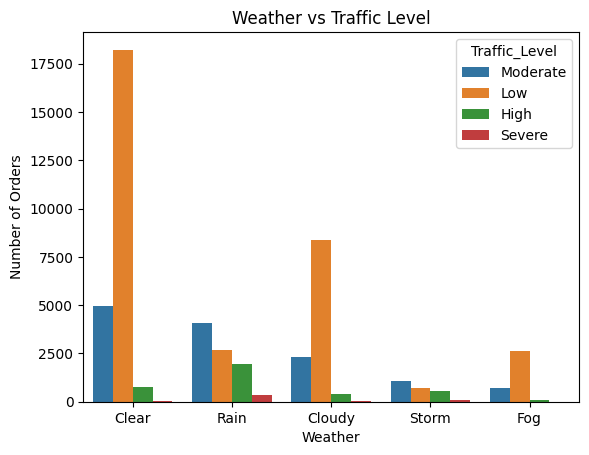

In [41]:
traffic_order = ['Moderate' , 'Low' , 'High' ,'Severe']
sns.countplot(x='Weather',hue='Traffic_Level',data=df,hue_order=traffic_order)
plt.title("Weather vs Traffic Level")
plt.xlabel("Weather")
plt.ylabel("Number of Orders")
plt.show()

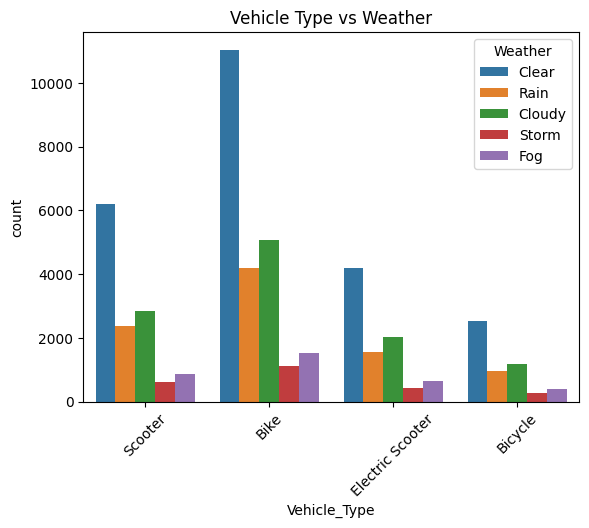

In [42]:
sns.countplot(x='Vehicle_Type', hue='Weather', data=df)
plt.title("Vehicle Type vs Weather")
plt.xticks(rotation=45)
plt.show()

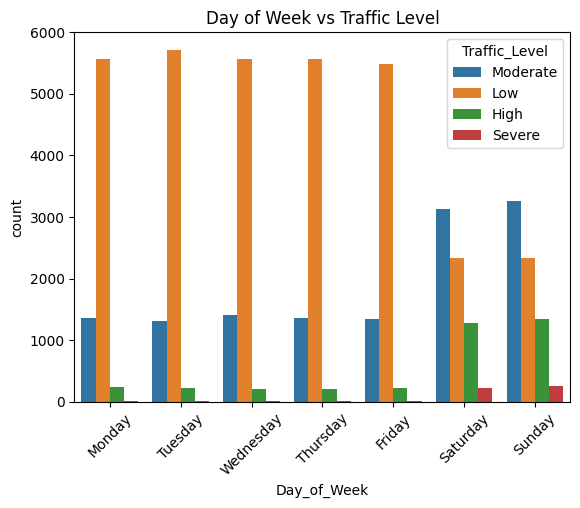

In [43]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='Day_of_Week', hue='Traffic_Level', data=df, order=day_order, hue_order=['Moderate' , 'Low' , 'High' ,'Severe'])
plt.title("Day of Week vs Traffic Level")
plt.xticks(rotation=45)
plt.show()

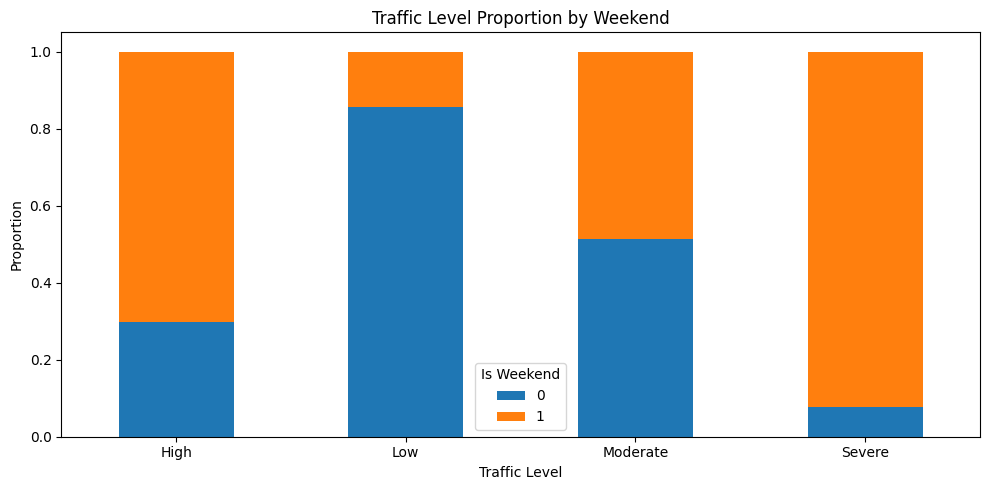

In [44]:
proportions = (df.groupby('Traffic_Level')['Is_Weekend'].value_counts(normalize=True).unstack())
proportions.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Traffic Level Proportion by Weekend')
plt.ylabel('Proportion')
plt.xlabel('Traffic Level')
plt.legend(title='Is Weekend')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

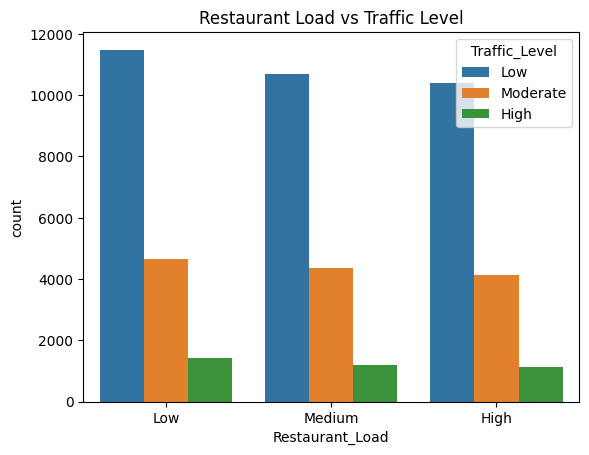

In [45]:
sns.countplot(x='Restaurant_Load', hue='Traffic_Level', data=df, order=['Low', 'Medium', 'High'], hue_order=['Low', 'Moderate', 'High'])
plt.title("Restaurant Load vs Traffic Level")
plt.show()

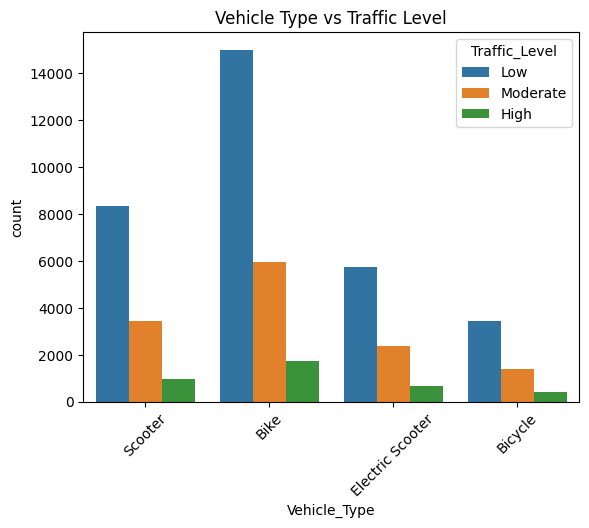

In [46]:
sns.countplot(x='Vehicle_Type',hue='Traffic_Level',data=df,hue_order=['Low', 'Moderate', 'High'])
plt.title("Vehicle Type vs Traffic Level")
plt.xticks(rotation=45)
plt.show()

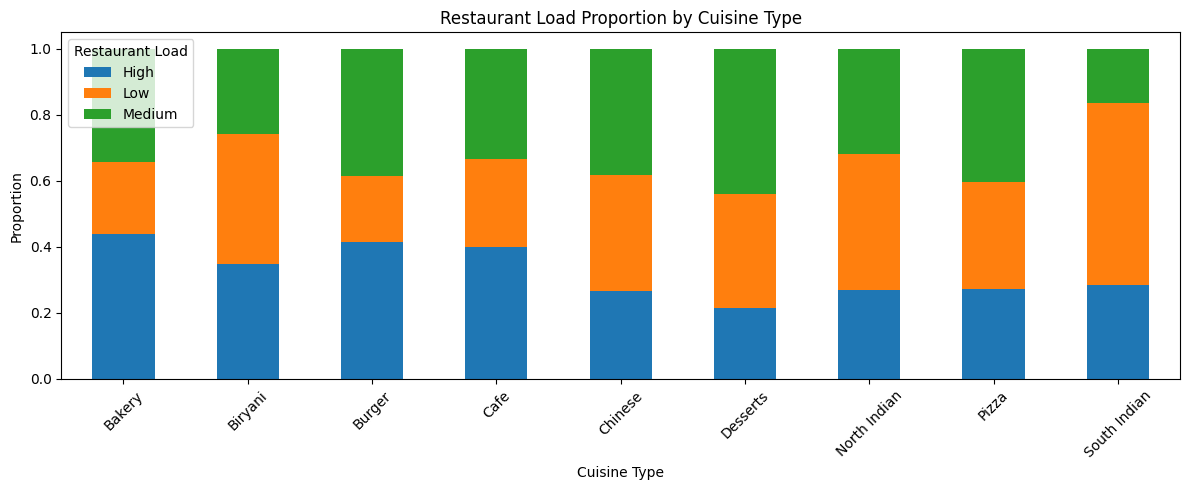

In [47]:
proportions = (df.groupby('Cuisine_Type')['Restaurant_Load'].value_counts(normalize=True).unstack())
proportions.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Restaurant Load Proportion by Cuisine Type')
plt.ylabel('Proportion')
plt.xlabel('Cuisine Type')
plt.legend(title='Restaurant Load')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
hour_analysis = (
    df.groupby("Order_Hour")["Time_taken_min"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

hour_analysis

,Order_Hour,count,mean,median
0,0,463,83.123110,76.0
1,1,471,80.993631,77.0
2,2,463,79.339093,74.0
3,3,507,80.735700,74.0
4,4,490,80.238776,75.0
5,5,956,80.468619,76.0
6,6,1985,80.772292,76.0
7,7,2471,81.497369,76.0
8,8,2476,87.696284,81.0
9,9,1982,87.196266,81.0


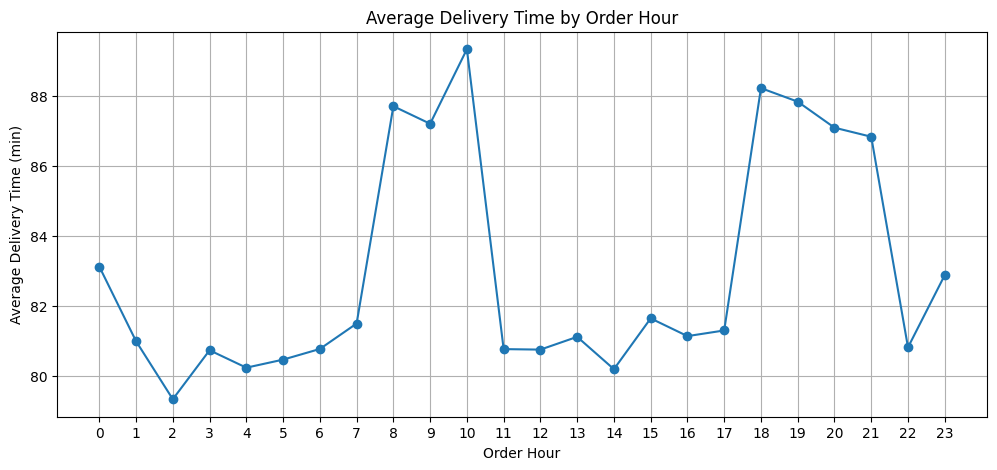

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_analysis["Order_Hour"],
    hour_analysis["mean"],
    marker="o"
)

plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (min)")
plt.title("Average Delivery Time by Order Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [50]:
threshold = hour_analysis["mean"].quantile(0.75)

peak_hours = hour_analysis.loc[
    hour_analysis["mean"] >= threshold,
    "Order_Hour"
].tolist()

peak_hours

[8, 9, 10, 18, 19, 20]

In [51]:
peak_hours = [8, 9, 10, 18, 19, 20]

df["Is_Peak_Hour"] = df["Order_Hour"].isin(peak_hours).astype(int)

In [52]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min',
       'Is_Peak_Hour'],
      dtype='object')

In [53]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min,Is_Peak_Hour
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91,1
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21,0
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,Low,31,10.15,Long,Moderate,8,28.9,Normal,52,1
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,Medium,19,26.33,Long,Low,9,41.4,Normal,59,0
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75,1


In [54]:
df.isna().sum()

,0
Order_ID,0
Order_Date,0
Order_Hour,0
Day_of_Week,0
Is_Weekend,0
Is_Festival,0
Weather,0
Pickup_Zone,0
Dropoff_Zone,0
Vehicle_Type,0


#**Processing**

Drop Columns

In [55]:
df.drop(
    ["Order_ID", "Order_Date", "Delivery_Distance_Category"],
    inplace=True,
    axis=1
)

Encoding


Ordinal Encoding

In [56]:
ordinal_maps = {
    'Traffic_Level': {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3},
    'Restaurant_Load': {'Low': 0, 'Medium': 1, 'High': 2},
    'Delivery_Priority': {'Normal': 0, 'Priority': 1, 'VIP': 2},
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

df[list(ordinal_maps.keys())].head()

,Traffic_Level,Restaurant_Load,Delivery_Priority
0,1,1,0
1,1,1,0
2,1,0,0
3,0,1,0
4,1,1,0


One Hot Encoding


In [57]:
nominal_cols = ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone',
                'Vehicle_Type', 'Cuisine_Type']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

df.shape
df.head()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,...,Vehicle_Type_Electric Scooter,Vehicle_Type_Scooter,Cuisine_Type_Biryani,Cuisine_Type_Burger,Cuisine_Type_Cafe,Cuisine_Type_Chinese,Cuisine_Type_Desserts,Cuisine_Type_North Indian,Cuisine_Type_Pizza,Cuisine_Type_South Indian
0,8,0,0,3.1,3.8,3.8,1,1,23,30.55,...,0,1,0,0,0,0,0,0,1,0
1,12,0,0,1.8,3.6,3.9,3,1,11,2.25,...,0,1,0,0,0,0,1,0,0,0
2,18,1,0,3.8,3.9,4.0,1,0,31,10.15,...,0,1,1,0,0,0,0,0,0,0
3,12,0,0,1.7,3.9,4.6,3,1,19,26.33,...,0,0,0,1,0,0,0,0,0,0
4,18,0,0,12.4,4.4,4.0,1,1,7,30.48,...,0,0,0,0,0,0,1,0,0,0


#Feature Engineering

In [58]:
df["Estimated_Travel_Time"] = (
    df["Road_Distance_km"] / df["Average_Speed_kmph"]
) * 60

In [59]:
df["Estimated_Travel_Time"]

,Estimated_Travel_Time
0,63.867596
1,5.793991
2,21.072664
3,38.159420
4,57.690852
...,...
49995,70.636364
49996,21.709091
49997,49.063291
49998,65.323944


In [60]:
df["Estimated_Total_Time"] = (
    df["Preparation_Time_Min"]
    + df["Estimated_Travel_Time"]
)

In [61]:
df["Signals_per_km"] = (
    df["Number_of_Signals"] / df["Road_Distance_km"]
)

In [62]:
df["Prep_Time_per_Item"] = (
    df["Preparation_Time_Min"] /
    df["Order_Items"]
)

In [63]:
df.drop(["Road_Distance_km", "Average_Speed_kmph", "Preparation_Time_Min", "Number_of_Signals", "Road_Distance_km", "Preparation_Time_Min", "Order_Items"], inplace=True, axis=1)

In [64]:
df.head()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Restaurant_Load,Traffic_Level,Delivery_Priority,Time_taken_min,...,Cuisine_Type_Cafe,Cuisine_Type_Chinese,Cuisine_Type_Desserts,Cuisine_Type_North Indian,Cuisine_Type_Pizza,Cuisine_Type_South Indian,Estimated_Travel_Time,Estimated_Total_Time,Signals_per_km,Prep_Time_per_Item
0,8,0,0,3.1,3.8,3.8,1,1,0,91,...,0,0,0,0,1,0,63.867596,86.867596,0.490998,23.000000
1,12,0,0,1.8,3.6,3.9,1,1,0,21,...,0,0,1,0,0,0,5.793991,16.793991,7.555556,3.666667
2,18,1,0,3.8,3.9,4.0,0,1,0,52,...,0,0,0,0,0,0,21.072664,52.072664,0.788177,31.000000
3,12,0,0,1.7,3.9,4.6,1,0,0,59,...,0,0,0,0,0,0,38.159420,57.159420,0.341815,6.333333
4,18,0,0,12.4,4.4,4.0,1,1,0,75,...,0,0,1,0,0,0,57.690852,64.690852,0.262467,7.000000


In [65]:
df["Estimated_Travel_Time"]

,Estimated_Travel_Time
0,63.867596
1,5.793991
2,21.072664
3,38.159420
4,57.690852
...,...
49995,70.636364
49996,21.709091
49997,49.063291
49998,65.323944


In [66]:
df["Time_taken_min"]

,Time_taken_min
0,91
1,21
2,52
3,59
4,75
...,...
49995,94
49996,54
49997,66
49998,92


In [67]:
!git clone https://github.com/NoraSamir581/SmartDeliveryTime.git

fatal: destination path 'SmartDeliveryTime' already exists and is not an empty directory.


In [69]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

/content/SmartDeliveryTime/Model/EDA1.ipynb


In [70]:

%cd /content/SmartDeliveryTime

/content/SmartDeliveryTime


In [71]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [72]:
!pwd
!ls

/content/SmartDeliveryTime
Dataset  Model


In [73]:
!ls /content/

'Food_Delivery_Time_Prediction[2].csv'	 sample_data   SmartDeliveryTime
